# PBQ-02 Resource Continuation: Data Hygiene + VaR/ES

This notebook is additive. It represents the extra PBQ-02 resource zips without changing the original lecture notebook or the earlier validated notebook. It runs offline from this folder using local `AXISBANK_data_hygiene.csv` and `TCS.NS.csv`.

## Configuration
Edit these file names only if you replace the local CSVs with equivalent files.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_HYGIENE_FILE = Path("AXISBANK_data_hygiene.csv")
TCS_FILE = Path("TCS.NS.csv")
VAR_LEVEL = 95
MONTE_CARLO_DAYS = 100
MONTE_CARLO_SIMS = 1000
RANDOM_SEED = 2022

print("Configured files:", DATA_HYGIENE_FILE, TCS_FILE)

Configured files: AXISBANK_data_hygiene.csv TCS.NS.csv


## Data Hygiene Auditor: offline checks
The official mini-project compares an uploaded market CSV against a trusted market source using `yfinance` and then asks an AI reviewer to explain the consequences. That live/API part is preserved as a resource reference. Here we run the offline checks that are possible without credentials or network access.

In [2]:
axis = pd.read_csv(DATA_HYGIENE_FILE)
axis["Date"] = pd.to_datetime(axis["Date"])
axis = axis.sort_values("Date").set_index("Date")

display(axis.head())
print("Rows:", len(axis))
print("Date range:", axis.index.min().date(), "to", axis.index.max().date())
print("Columns:", list(axis.columns))

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2000-01-03,UTIBANK,EQ,24.70,26.7,26.70,26.70,26.7,26.70,26.70,112100,2.993070e+11,NaN,NaN,NaN
2000-01-04,UTIBANK,EQ,26.70,27.0,28.70,26.50,27.0,26.85,27.24,234500,6.387275e+11,NaN,NaN,NaN
2000-01-05,UTIBANK,EQ,26.85,26.0,27.75,25.50,26.4,26.30,26.24,170100,4.462980e+11,NaN,NaN,NaN
2000-01-06,UTIBANK,EQ,26.30,25.8,27.00,25.80,25.9,25.95,26.27,102100,2.681730e+11,NaN,NaN,NaN
2000-01-07,UTIBANK,EQ,25.95,25.0,26.00,24.25,25.0,24.80,25.04,62600,1.567220e+11,NaN,NaN,NaN


Rows: 5306
Date range: 2000-01-03 to 2021-04-30
Columns: ['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']


### Audit missing values and structural issues
These checks catch common data failures before a strategy sees the data: duplicated dates, missing values, impossible OHLC relationships, non-positive volume, and unusually large close-to-close jumps.

In [3]:
missing_counts = axis.isna().sum().sort_values(ascending=False)
business_days = pd.bdate_range(axis.index.min(), axis.index.max())
missing_business_days = business_days.difference(axis.index)
ohlc_bad = axis[(axis["High"] < axis[["Open", "Close", "Low"]].max(axis=1)) | (axis["Low"] > axis[["Open", "Close", "High"]].min(axis=1))]
non_positive_volume = axis[axis["Volume"] <= 0]
close_ret = axis["Close"].pct_change()
large_moves = close_ret[close_ret.abs() > 0.25]

summary = pd.read_csv("pbq02_data_hygiene_summary.csv")
display(summary)
print("Missing business-day proxy count:", len(missing_business_days))
print("First five missing business-day proxy dates:", [d.date().isoformat() for d in missing_business_days[:5]])

,check,result,severity,interpretation
0,rows,5306,info,Number of submitted rows.
1,date_range_start,2000-01-03,info,First date after parsing.
2,date_range_end,2021-04-30,info,Last date after parsing.
3,duplicate_dates,0,pass,Duplicate dates can double-count or overwrite ...
4,missing_business_days_proxy,283,warning,Business-day proxy; exchange holidays require ...
5,ohlc_order_violations,0,pass,High should be at least Open/Close/Low and Low...
6,non_positive_volume,0,pass,Zero or negative volume is suspicious for acti...
7,large_absolute_close_moves_gt_25pct,2,warning,Large close-to-close moves may be real corpora...
8,missing_values_Trades,2850,warning,Trades contains missing values.
9,missing_values_Deliverable Volume,509,warning,Deliverable Volume contains missing values.


Missing business-day proxy count: 283
First five missing business-day proxy dates: ['2000-01-26', '2000-03-17', '2000-03-20', '2000-04-14', '2000-04-21']


### Visual audit
The chart keeps the audit readable: price history, missing columns, return outliers, and severity counts. The business-day gap count is a proxy because exchange holidays require an official NSE calendar before every gap can be called an error.

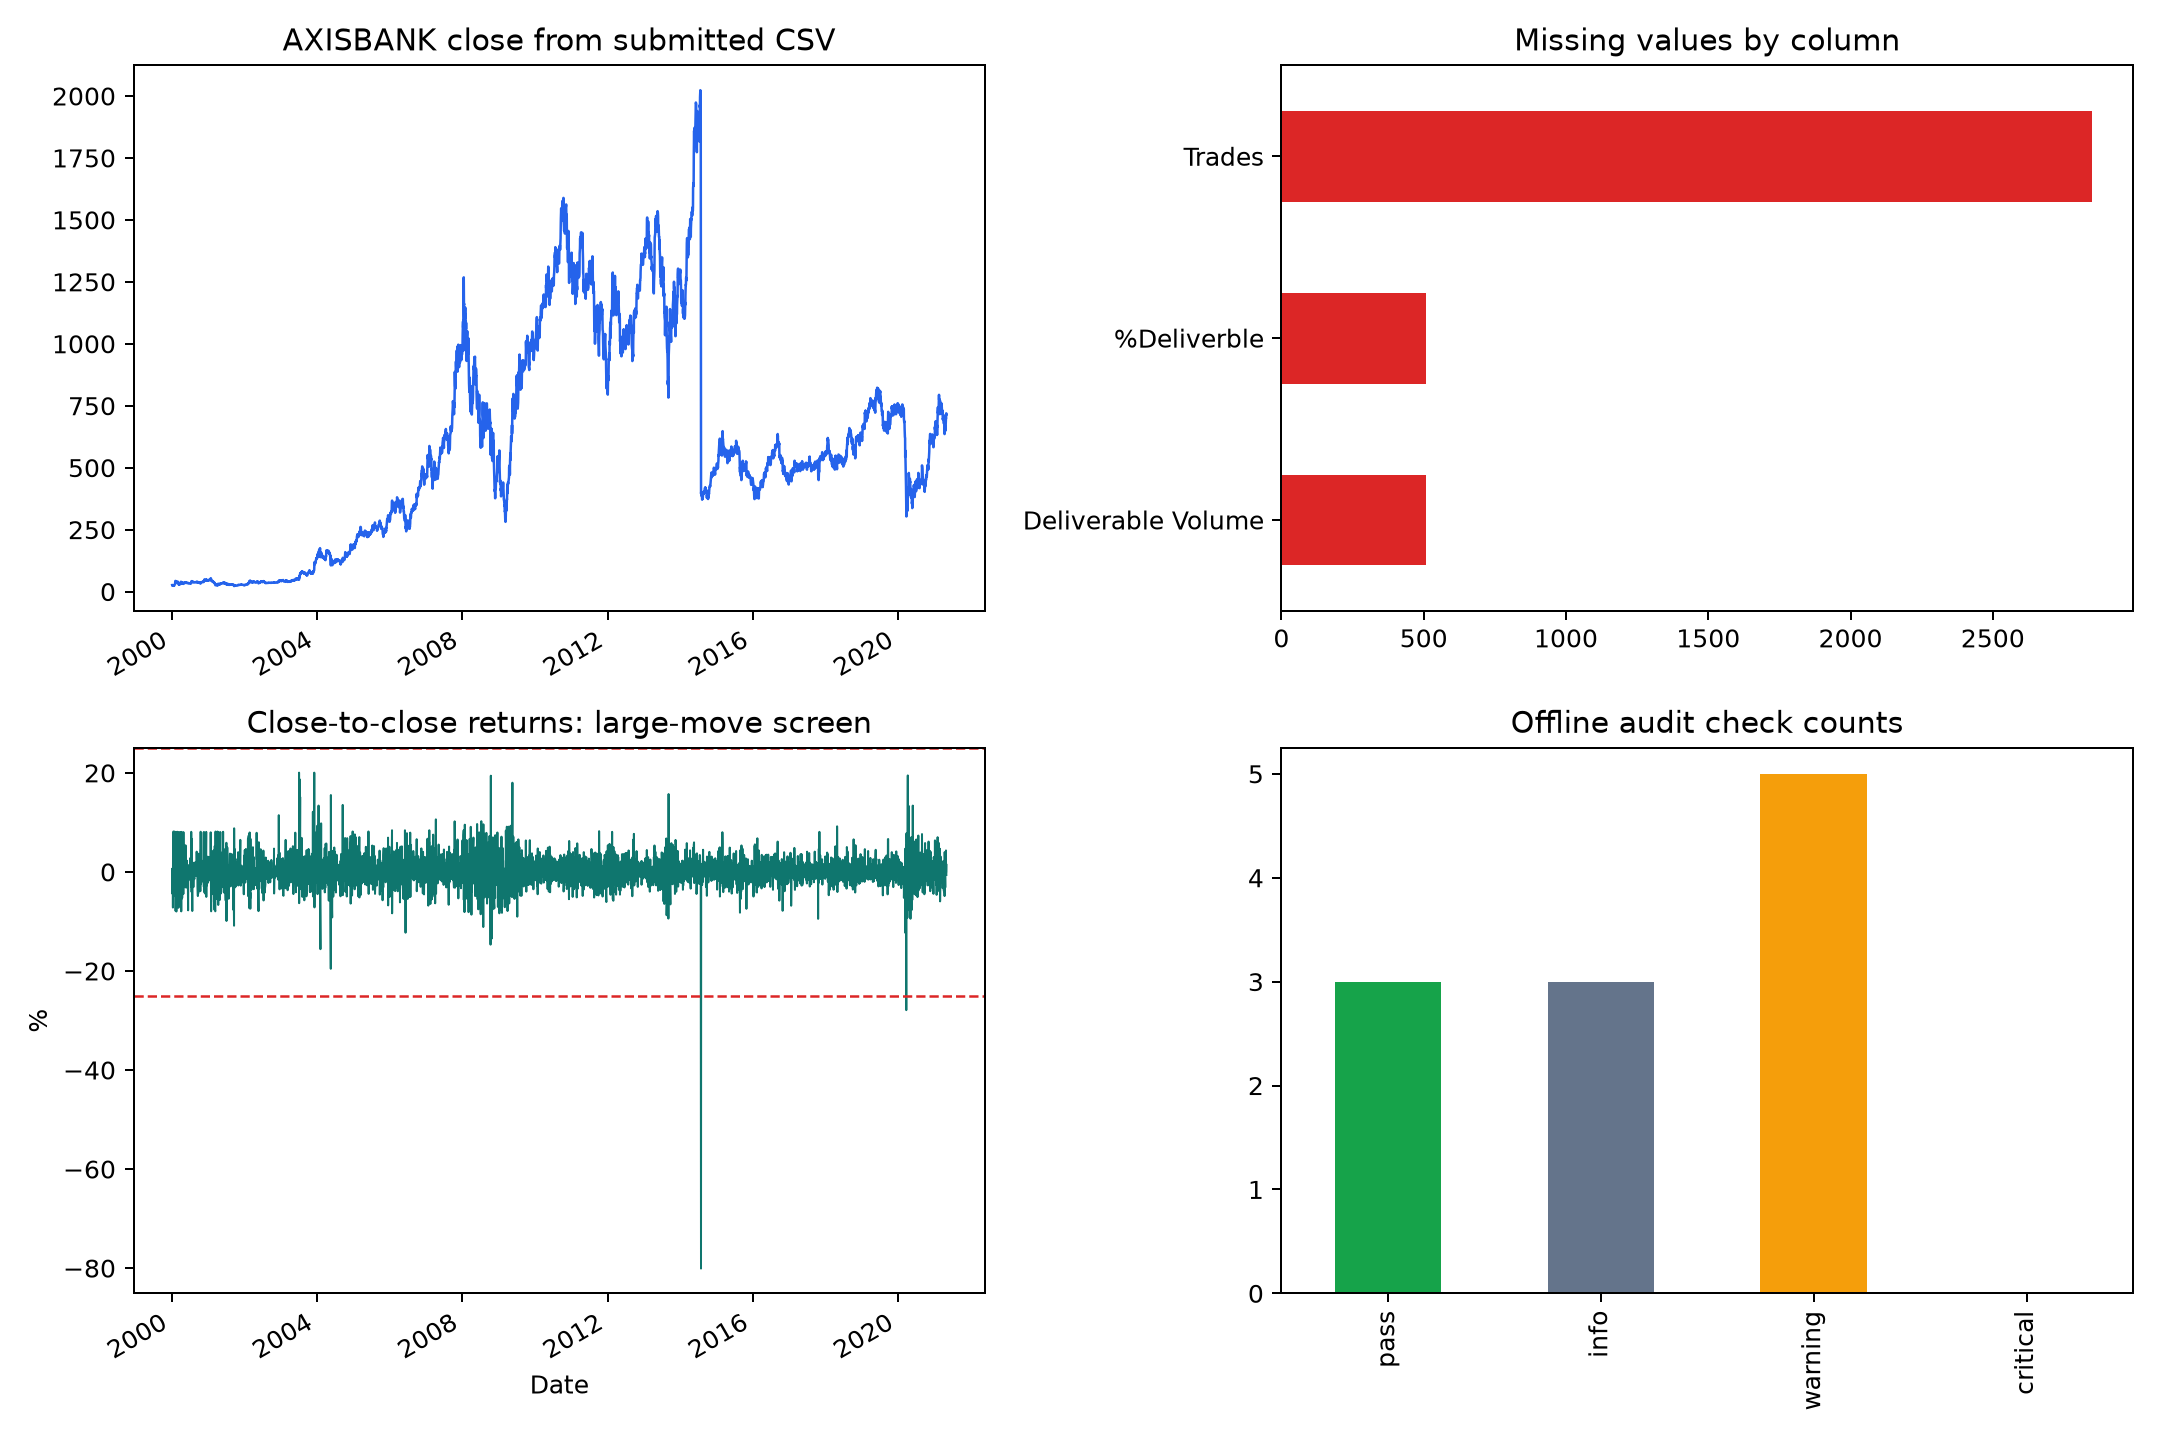

In [4]:
from IPython.display import Image, display

display(Image(filename="chart_continuation_1_pbq02_data_hygiene.png"))

## FAQ addendum: `np.where`, `df.where`, boolean slicing, and fixed parameters
The PBQ-02 FAQ adds practical variants students often ask about. The examples below are deliberately small and then tied back to the TCS file.

In [5]:
sample = pd.DataFrame({"price": [98, 101, 100, 104], "volume": [900, 1500, 1200, 2100]})

# np.where returns a NumPy array, useful for compact vectorized labels.
sample["np_where_signal"] = np.where(sample["price"] > 100, "above_100", "not_above_100")

# df.where keeps the original shape and replaces rows that fail the condition with NaN.
where_result = sample.where(sample["volume"] > 1200)

# Boolean slicing returns only the rows that satisfy the condition.
boolean_slice = sample[sample["volume"] > 1200]

display(sample)
display(where_result)
display(boolean_slice)

,price,volume,np_where_signal
0,98,900,not_above_100
1,101,1500,above_100
2,100,1200,not_above_100
3,104,2100,above_100


,price,volume,np_where_signal
0,NaN,NaN,NaN
1,101.0,1500.0,above_100
2,NaN,NaN,NaN
3,104.0,2100.0,above_100


,price,volume,np_where_signal
1,101,1500,above_100
3,104,2100,above_100


### Nested `np.where` and tuples for immutable algo configuration
Nested `np.where` is the vectorized equivalent of a three-way `if/elif/else`. Tuples are useful for fixed strategy settings that should not be changed accidentally.

In [6]:
strategy_config = (20, 50, "long_only")  # short MA, long MA, trading mode: immutable by convention
sample["three_way_signal"] = np.where(sample["price"] > 102, 1, np.where(sample["price"] < 100, -1, 0))

display(sample)
print("Strategy config tuple:", strategy_config)
print("Tuple has no append method:", hasattr(strategy_config, "append"))

,price,volume,np_where_signal,three_way_signal
0,98,900,not_above_100,-1
1,101,1500,above_100,0
2,100,1200,not_above_100,0
3,104,2100,above_100,1


Strategy config tuple: (20, 50, 'long_only')
Tuple has no append method: False


## Monte Carlo VaR/ES mini-project: offline TCS version
The official mini-project downloads AAPL with `yfinance`. To keep this folder runnable offline, the same workflow is applied to the provided TCS data: daily returns, historical VaR/CVaR, parametric VaR/CVaR, square-root scaling, and Monte Carlo simulation.

In [7]:
tcs = pd.read_csv(TCS_FILE)
tcs["Date"] = pd.to_datetime(tcs["Date"], dayfirst=True)
tcs = tcs.sort_values("Date").set_index("Date")
tcs["daily_returns"] = tcs["Adj Close"].pct_change()
rets = tcs["daily_returns"].dropna()
rets_pct = rets * 100

display(tcs[["Adj Close", "daily_returns"]].head())
print("Return observations:", len(rets))

,Adj Close,daily_returns
Date,,
2015-11-18,1038.072876,NaN
2015-11-19,1042.982178,0.004729
2015-11-20,1058.786377,0.015153
2015-11-23,1055.563843,-0.003044
2015-11-24,1045.357300,-0.009669


Return observations: 1230


### Historical and parametric VaR/CVaR
Historical VaR uses the empirical 5th percentile. Historical CVaR/expected shortfall averages returns worse than that percentile. Parametric VaR assumes a normal distribution with the same mean and volatility.

In [8]:
var_summary = pd.read_csv("pbq02_var_es_summary.csv")
display(var_summary)

,metric,value,units
0,observations,1230.000000,daily returns
1,mean_daily_return_pct,0.087318,percent
2,daily_volatility_pct,1.628297,percent
3,skewness,0.063450,unitless
4,excess_kurtosis,4.026144,unitless
5,shapiro_pvalue_sample_500,NaN,p-value
6,historical_var_95_pct,-2.431395,percent return
7,historical_cvar_95_pct,-3.613152,percent return
8,parametric_var_95_pct,-2.589529,percent return
9,parametric_cvar_95_pct,NaN,percent return


### Monte Carlo paths
The simulation uses log-return drift and volatility from the TCS data, a fixed random seed for reproducibility, and 1,000 paths for 100 trading days.

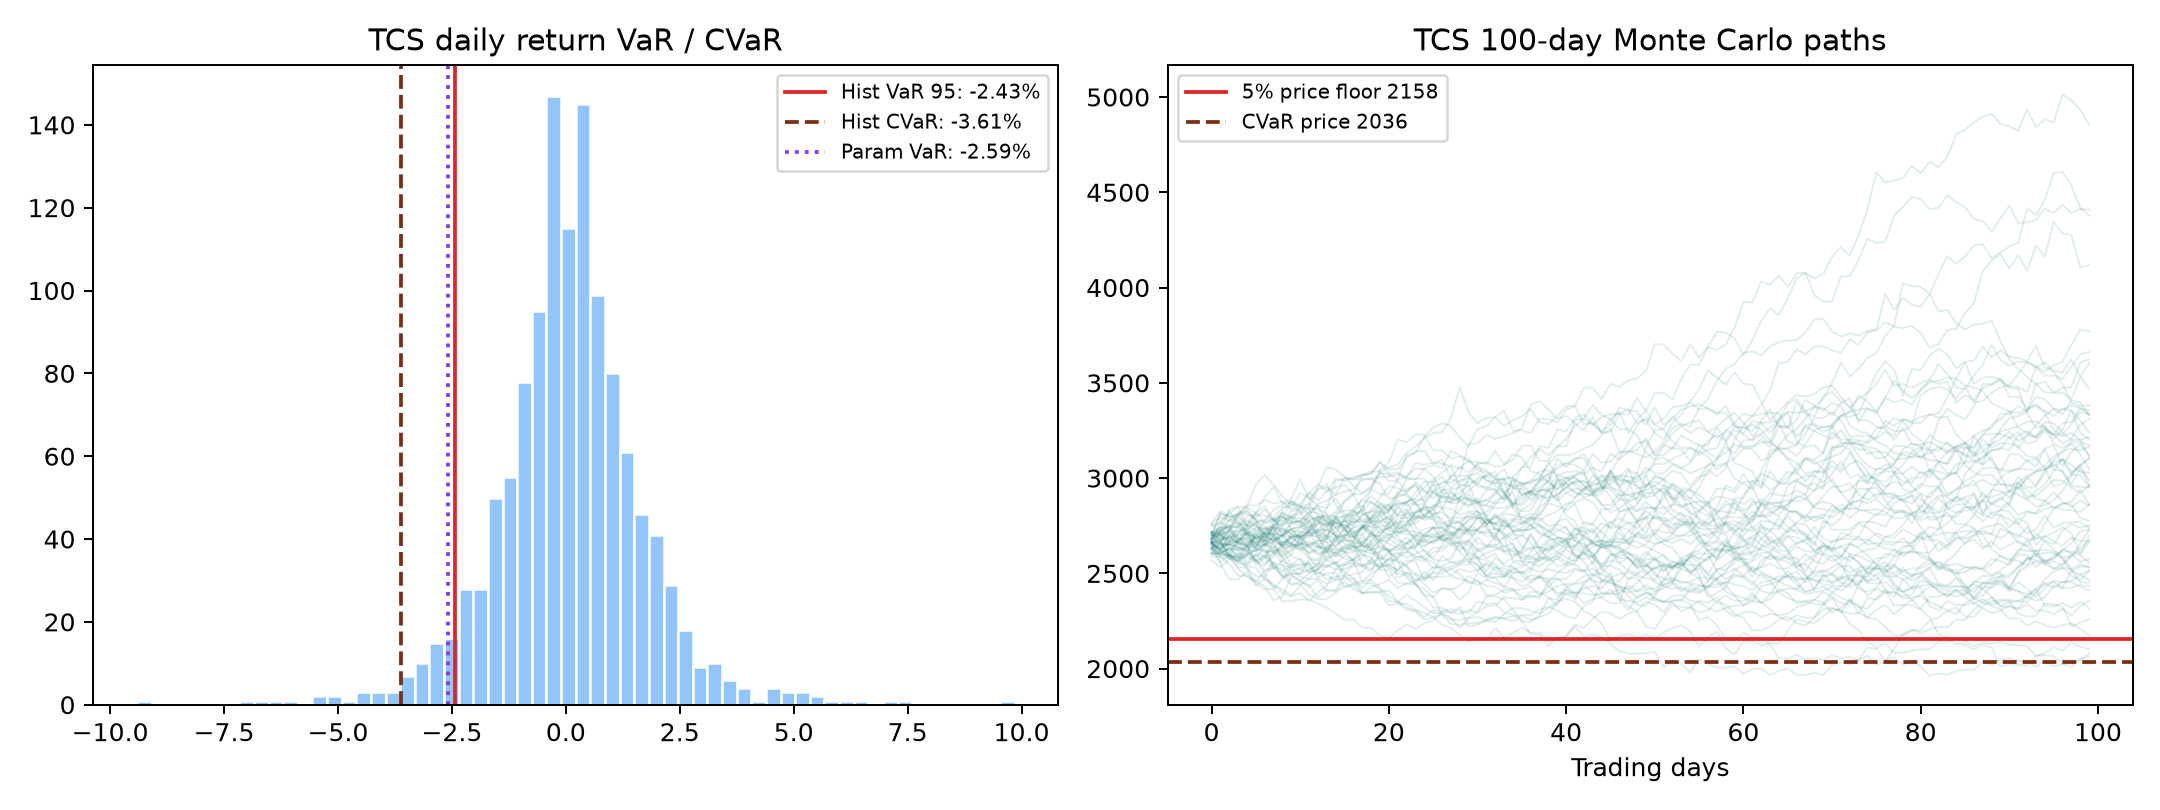

In [9]:
display(Image(filename="chart_continuation_2_pbq02_var_es.png"))

## Final interpretation
The extra resources extend PBQ-02 in two directions. Data hygiene shows why `read_csv`, missing-value checks, and validation must happen before research. The VaR/ES project shows how NumPy and pandas become risk tools once you can compute returns, percentiles, rolling statistics, and simulations.